In [43]:
import sys, os
from omegaconf import OmegaConf
import torch
import numpy as np
import pandas as pd
import glob
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm
sys.path.append("/home/jgershon/git/cleo/reinforced_mpnn")
sys.path.append("/projects/ml/itopt/policy_mpnn/software/pipelines/pipelines/blocks")
from policy_utils import PolicyMPNN, alphabet
import random
import secrets

def get_pairwise_dists(all_seqs):
        
        all_dists = []
        for i in range(len(all_seqs)):
            for j in range(len(all_seqs)):
                if i < j:
                    dist = 1 - (sum([1 for a, b in zip(all_seqs[i], all_seqs[j]) if a != b]) / len(all_seqs[i]))
                    all_dists.append(dist)

        return all_dists

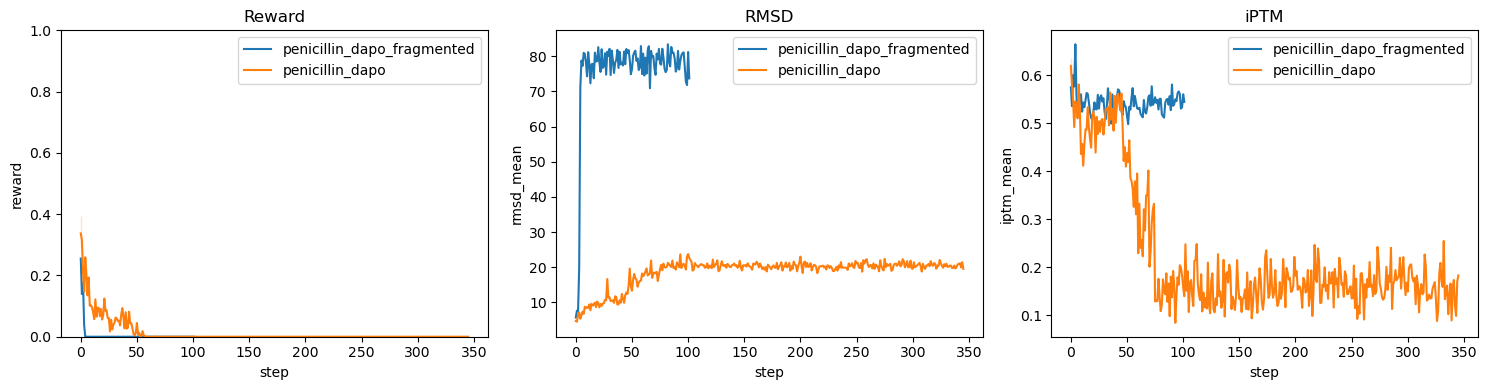

In [46]:
path = "/home/jgershon/projects/itopt/policy_mpnn/test_runs/test_penicillin_train_metrics.csv"

path = "/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg/penicillin_vanilla_pg_train_metrics.csv"
df = pd.read_csv(path)

base_path = "/home/jgershon/projects/itopt/policy_mpnn"

fig, ax = plt.subplots(1,3,figsize=(15, 4))

def plot_metrics(folder, label, base_path=base_path, fig=fig, ax=ax):
    
    path = os.path.join(base_path, folder, "*train_metrics.csv")
    train_metrics_path = glob.glob(path)[0]
    df = pd.read_csv(train_metrics_path)


    sns.lineplot(data=df, x="step", y="reward", label=label, ax=ax[0])
    ax[0].set_title("Reward")
    ax[0].set_ylim(0, 1)

    sns.lineplot(data=df, x="step", y="rmsd_mean", label=label, ax=ax[1])
    ax[1].set_title("RMSD")
    # ax[1].set_ylim(0, 10)

    sns.lineplot(data=df, x="step", y="iptm_mean", label=label, ax=ax[2])
    ax[2].set_title("iPTM")

to_plot = [
    # PENICILLIN
    # ("penicillin_vanilla_pg","penicillin_run",),
    # ("penicillin_vanilla_pg_fragmented","penicillin_run_fragmented",),
    # ("penicillin_vanilla_pg_fragmented_rmsd_correct","penicillin_fragmented",),
    ("penicillin_dapo_fragmented","penicillin_dapo_fragmented"),
    ("penicillin_dapo","penicillin_dapo"),


    # ("penicillin_vanilla_pg_fragmented_T0.1", "penicillin_run_fragmented_T0.1",),
    # ("penicillin_vanilla_pg_fragmented_T0.25", "penicillin_run_fragmented_T0.25",),
    # ("penicillin_vanilla_pg_fragmented_T0.5", "penicillin_run_fragmented_T0.5",),
    
    # HEME
    # ("heme_vanilla_pg","heme_run",),
    # ("heme_vanilla_pg_proteinMPNN","heme_run_proteinMPNN",),
    # ("heme_vanilla_pg_proteinMPNN_fragmented","heme_run_proteinMPNN_fragmented",),



    # PROTEASE
    # ("protease_vanilla_pg","protease_run",),
    # ("protease_vanilla_pg_again","protease_run_again",),
    # ("protease_vanilla_pg_2frag","protease_run_2frag",),
    # ("protease_vanilla_pg_3frag","protease_run_3frag",),
    # ("protease_vanilla_pg_4frag","protease_run_4frag",),
    # ("protease_vanilla_pg_2resiFRAG", "protease_run_2resiFRAG",),
    # ("protease_vanilla_pg_ASfrags_v1", "protease_run_ASfrags_v1",),
    # ("protease_vanilla_pg_ASfrags_v1_lr1e5", "protease_run_ASfrags_v1_lr1e5",),


    # ("protease_vanilla_pg_fragmented_5frag","protease_run_fragmented_5frag",),
    # ("protease_vanilla_pg_fragmented","protease_run_fragmented",)
    # ("protease_vanilla_pg_fragmented_r2","protease_run_fragmented_2",),
    # ("protease_vanilla_pg_fragmented_lg_batch", "protease_fragmented")


]

for p in to_plot:
    plot_metrics(p[0], p[1], base_path=base_path, fig=fig, ax=ax)

plt.tight_layout()


Text(0.5, 1.0, 'Sequence Similarity | temp=1.0')

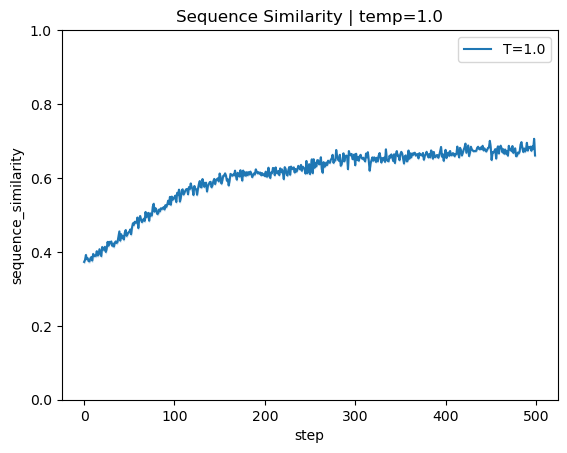

In [19]:

def get_stepwise_diversity(folder, base_path=base_path):

    search_path = os.path.join(base_path,folder,"pipeline_output/*/*.csv")
    files = glob.glob(search_path)

    datas = {
        "step": [],
        "sequence_similarity": [],
    }

    for f in files:
        tmp = pd.read_csv(f)
        all_seqs = tmp["sequence"].tolist()
        all_dists = get_pairwise_dists(all_seqs)
        datas["step"].extend([int(f.split("/")[-2].split("_")[-1])] * len(all_dists))
        datas["sequence_similarity"].extend(all_dists)

    return pd.DataFrame(datas)

df = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_rmsd_correct")
# df_T01 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_T0.1")
# df_T025 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_T0.25")
# df_T05 = get_stepwise_diversity("penicillin_vanilla_pg_fragmented_T0.5")


sns.lineplot(data=df, x="step", y="sequence_similarity", label="T=1.0",)
# sns.lineplot(data=df_T01, x="step", y="sequence_similarity", label="T=0.1")
# sns.lineplot(data=df_T025, x="step", y="sequence_similarity", label="T=0.25")
# sns.lineplot(data=df_T05, x="step", y="sequence_similarity", label="T=0.5")
plt.ylim(0, 1)

plt.title("Sequence Similarity | temp=1.0")


In [40]:
x = torch.randn(10,5,4)
idx = torch.randperm(10)


x[idx[:5]]

tensor([[[ 3.1920,  1.8946,  1.2913, -0.3239],
         [ 1.3198,  1.0575,  1.7190, -0.1796],
         [ 0.5585,  2.4630, -0.7199,  0.9596],
         [ 0.8395, -0.0175,  1.2678, -0.3058],
         [ 0.0814,  0.6355,  0.4045, -0.6292]],

        [[ 1.3253, -0.7924, -2.9310, -0.3194],
         [-0.4930,  1.2176, -1.1292,  2.5954],
         [ 1.4334,  0.0462,  0.6649,  0.6404],
         [-2.2225, -0.1051, -0.7357, -0.0346],
         [ 0.1463, -0.7405, -1.1391,  1.9290]],

        [[ 0.6810,  1.8454, -1.4638, -1.2215],
         [-1.9479,  1.0662, -0.1712,  1.2700],
         [ 0.5117,  0.0074, -0.0339, -1.3863],
         [ 1.6732,  0.7849, -0.1979, -1.2415],
         [ 1.4328, -0.9646, -1.2746, -0.4691]],

        [[-1.5829,  2.7186, -0.3671,  0.7701],
         [-0.8611, -1.7179, -1.3011, -2.3370],
         [ 1.6361, -0.9383, -0.1949, -1.5039],
         [ 0.5418,  0.4557,  1.7712, -0.0208],
         [-1.0415, -0.5861, -1.5602,  0.5801]],

        [[-0.1727, -0.0774,  0.2156,  1.9992],
     

In [42]:
[x[8]]

[tensor([[ 0.6810,  1.8454, -1.4638, -1.2215],
         [-1.9479,  1.0662, -0.1712,  1.2700],
         [ 0.5117,  0.0074, -0.0339, -1.3863],
         [ 1.6732,  0.7849, -0.1979, -1.2415],
         [ 1.4328, -0.9646, -1.2746, -0.4691]])]

In [18]:
# for penicillin enzyme
fragment_bounds = [(0,29),(30,66),(67,102),(103,130),(131,157)]


# for heme enzyme
# fragment_bounds = [(0,24),(25,49),(50,74),(75,99),(100,124),(125,149),(150,174),(175,199),(200,224),(225,251)]


: 

In [ ]:
fragment_bounds = [(0,24),(25,49),(50,74),(75,99),(100,124),(125,149),(150,184)]


: 

In [53]:
import biotite.structure.io as strucio

sys.path.append("/home/jgershon")
from pdb_util import get_rmsd


motif_residues = [50, 69, 72, 121, 229, 232]


# # setting up elliot benchmark
# ref_path = "/home/jgershon/from/elliot/elliot_design.pdb"
# des_path = "/home/jgershon/from/elliot/elliot_af3.cif"

# # elliot case
# motif_atoms = {
#     "A50": ["CB", "CG", "OD1", "OD2"],
#     "A69": ["CB", "CG", "ND1", "CD2", "CE1", "NE2"],
#     "A72": ["CB", "CSG"],
#     "A121": ["CB", "CG", "ND1", "CD2", "CE1", "NE2"],
#     "A229": ["CB", "CG", "ND1", "CD2", "CE1", "NE2"],
#     "A232": ["CB", "CG", "ND1", "CD1", "CD2", "CE1", "CE2", "CZ"],
# }




# saman case
ref_path = "/projects/ml/itopt/policy_mpnn/benchmarks/penicillin_enzyme/pd_input_make2.pdb"
des_path = "/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0002/seq_0002_model.cif"
motif_atoms = {
    "A140": ["C", "O"],
    "A141": ["N", "CA", "C", "O"],
    "A142": ["SG", "CB", "CA", "N", "C", "O"],
    "A17": ["NE2", "CE1", "ND1", "CD2", "CG", "CB"],
    "A37": ["OD2", "OD1", "CG", "CB"],
}


: 

In [59]:


ref_atoms = strucio.load_structure(ref_path)
des_atoms = strucio.load_structure(des_path)


# for reference
ref_atoms.add_annotation("is_motif", np.dtype(bool))
ref_atoms.set_annotation("is_motif", np.full(len(ref_atoms), False))

# set atoms in the motif to True 
for resi in motif_atoms:
    chain = resi[0]
    idx = int(resi[1:])
    chain_and_idx_mask = (ref_atoms.res_id == idx) & (ref_atoms.chain_id == chain)
    atoms = motif_atoms[resi]
    mask = chain_and_idx_mask & np.isin(ref_atoms.atom_name, atoms)
    ref_atoms.is_motif[mask] = True

# copy annotation to is_motif_atom
ref_atoms.add_annotation("is_motif_atom", np.dtype(bool))
ref_atoms.set_annotation("is_motif_atom", ref_atoms.is_motif.copy())



# for design
des_atoms.add_annotation("is_motif", np.dtype(bool))
des_atoms.set_annotation("is_motif", np.full(len(des_atoms), False))

# set atoms in the motif to True 
for resi in motif_atoms:
    chain = resi[0]
    idx = int(resi[1:])
    chain_and_idx_mask = (des_atoms.res_id == idx) & (des_atoms.chain_id == chain)
    atoms = motif_atoms[resi]
    mask = chain_and_idx_mask & np.isin(des_atoms.atom_name, atoms)
    des_atoms.is_motif[mask] = True

# copy annotation to is_motif_atom
des_atoms.add_annotation("is_motif_atom", np.dtype(bool))
des_atoms.set_annotation("is_motif_atom", des_atoms.is_motif.copy())


/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_comp_id' not found within 'atom_site' category. The fallback attribute 'label_comp_id' will be used instead
  warnings.warn(
/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_atom_id' not found within 'atom_site' category. The fallback attribute 'label_atom_id' will be used instead
  warnings.warn(


: 

: 

In [63]:
ref_motif_atoms = ref_atoms[ref_atoms.is_motif_atom]
des_motif_atoms = des_atoms[des_atoms.is_motif_atom]

get_rmsd(torch.tensor(ref_motif_atoms.coord), torch.tensor(des_motif_atoms.coord))

(tensor(1.7932),
 tensor([[-0.4409,  0.4031, -0.8020],
         [-0.4378, -0.8766, -0.1999],
         [-0.7836,  0.2629,  0.5629]]))

: 

In [62]:
ref_motif_atoms.coord

array([[ 22.909, -27.934,  -6.989],
       [ 21.798, -28.928,  -6.861],
       [ 21.691, -30.207,  -7.291],
       [ 20.61 , -28.639,  -6.223],
       [ 19.821, -29.699,  -6.265],
       [ 20.455, -30.663,  -6.907],
       [ 18.449, -26.11 ,  -2.501],
       [ 19.403, -27.111,  -3.14 ],
       [ 19.616, -28.151,  -2.565],
       [ 19.909, -26.825,  -4.2  ],
       [ 14.887, -36.549,  -9.15 ],
       [ 13.742, -36.155,  -9.408],
       [ 15.425, -36.483,  -7.908],
       [ 14.684, -35.923,  -6.785],
       [ 14.595, -34.406,  -6.885],
       [ 13.596, -33.773,  -6.517],
       [ 15.755, -33.833,  -7.431],
       [ 15.833, -32.377,  -7.451],
       [ 14.794, -31.781,  -8.392],
       [ 14.25 , -30.703,  -8.124],
       [ 17.211, -31.909,  -7.868],
       [ 18.498, -32.48 ,  -6.679]], dtype=float32)

: 

In [57]:

for x,y in zip(ref_motif_atoms.atom_name.tolist(), des_motif_atoms.atom_name.tolist()):
    print(x, y)

CB CB
CG CG
CD2 ND1
ND1 CD2
CE1 CE1
NE2 NE2
CB CB
CG CG
OD1 OD1
OD2 OD2
C C
O O
N N
CA CA
C C
O O
N SG
CA CB
C CA
O N
CB C
SG O


: 

In [92]:

# with sorted atom arrays

ref_atoms = strucio.load_structure(ref_path)
des_atoms = strucio.load_structure(des_path)


ref_motif_atom_coord_list = []
# set atoms in the motif to True 
for resi in motif_atoms:
    chain = resi[0]
    idx = int(resi[1:])
    chain_and_idx_mask = (ref_atoms.res_id == idx) & (ref_atoms.chain_id == chain)
    
    atoms = motif_atoms[resi]
    _atom_names = ref_atoms[chain_and_idx_mask].atom_name
    _atom_coords = ref_atoms[chain_and_idx_mask].coord

    for a in atoms:
        _xyz = _atom_coords[_atom_names == a]
        ref_motif_atom_coord_list.append(_xyz)

ref_motif_atom_coord = torch.tensor(np.concatenate(ref_motif_atom_coord_list, axis=0))


des_motif_atom_coord_list = []

# set atoms in the motif to True 
for resi in motif_atoms:
    chain = resi[0]
    idx = int(resi[1:])
    chain_and_idx_mask = (des_atoms.res_id == idx) & (des_atoms.chain_id == chain)
    atoms = motif_atoms[resi]

    _atom_names = des_atoms[chain_and_idx_mask].atom_name
    _atom_coords = des_atoms[chain_and_idx_mask].coord

    for a in atoms:
        _xyz = _atom_coords[_atom_names == a]
        des_motif_atom_coord_list.append(_xyz)

des_motif_atom_coord = torch.tensor(np.concatenate(des_motif_atom_coord_list, axis=0))


/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_comp_id' not found within 'atom_site' category. The fallback attribute 'label_comp_id' will be used instead
  warnings.warn(
/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_atom_id' not found within 'atom_site' category. The fallback attribute 'label_atom_id' will be used instead
  warnings.warn(


: 

In [93]:
get_rmsd(ref_motif_atom_coord, des_motif_atom_coord)

(tensor(1.0714),
 tensor([[-0.4825,  0.3946, -0.7820],
         [-0.4117, -0.8902, -0.1952],
         [-0.7731,  0.2277,  0.5919]]))

: 

array([[ 14.887, -36.549,  -9.15 ],
       [ 13.742, -36.155,  -9.408],
       [ 14.595, -34.406,  -6.885],
       [ 13.596, -33.773,  -6.517],
       [ 14.794, -31.781,  -8.392],
       [ 14.25 , -30.703,  -8.124],
       [ 21.835, -26.555,  -8.746],
       [ 20.914, -27.04 ,  -9.415],
       [ 19.167, -26.293,  -0.12 ],
       [ 19.836, -27.26 ,   0.27 ]], dtype=float32)

: 

In [81]:


_atom_names = ref_atoms[chain_and_idx_mask].atom_name
_atom_coords = ref_atoms[chain_and_idx_mask].coord

for a in atoms:
    _xyz = _atom_coords[_atom_names == a]


: 

In [82]:
_xyz

array([[ 13.742, -36.155,  -9.408]], dtype=float32)

: 

In [77]:
[int(x) for x in np.argsort(atoms)]

[0, 1]

: 

In [72]:
np.argsort(atoms).astype(np.int32)

array([0, 1], dtype=int32)

: 

: 

In [44]:
ref_atoms[(ref_atoms.chain_id == "D")].atom_name

array(['C1A', 'NA', 'C4A', 'CHB', 'C1B', 'NB', 'C4B', 'CHC', 'C1C', 'C2C',
       'CMC', 'C3C', 'CAC', 'CBC', 'C4C', 'CHD', 'C1D', 'ND', 'C4D',
       'CHA', 'C3D', 'CAD', 'CBD', 'CGD', 'O1D', 'O2D', 'C2D', 'CMD',
       'ZN1', 'NC', 'C3B', 'CAB', 'CBB', 'C2B', 'CMB', 'C3A', 'CMA',
       'C2A', 'CAA', 'CBA', 'CGA', 'O1A', 'O2A'], dtype='<U6')

: 

In [ ]:
for r in motif_residues:
    ref_sub = ref_atoms[(ref_atoms.chain_id == "A") & (ref_atoms.res_id == r)]
    des_sub = des_atoms[(des_atoms.chain_id == "A") & (des_atoms.res_id == r)]

    if r == 232:
        break

: 

In [3]:
ref_path = "/projects/ml/itopt/policy_mpnn/benchmarks/protease/promising_24_hojae.cif"
des_path = "/home/jgershon/tmp/test/test_model.cif"
import biotite.structure.io as strucio

sys.path.append("/home/jgershon")
from pdb_util import get_rmsd


motif_residues = [50, 69, 72, 121, 229, 232]

motif_atoms = {
    "A40": ["CB", "CG", "ND2", "OD1"],
    "A43": ["CB", "CG", "ND2", "OD1"],
    "A44": ["O"],
    "A45": ["CG", "CD2", "ND1", "CE1", "NE2"],
    "A60": ["CB", "CG", "OD1", "OD2"],
    "A65": ["CG", "ND2", "OD1"],
    "A100": ["CB","SG"],
    "B7": ["N"],
    "B8": ["N"],
}

ref_atoms = strucio.load_structure(ref_path)
des_atoms = strucio.load_structure(des_path)


/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_seq_id' not found within 'atom_site' category. The fallback attribute 'label_seq_id' will be used instead
  warnings.warn(
/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_comp_id' not found within 'atom_site' category. The fallback attribute 'label_comp_id' will be used instead
  warnings.warn(
/home/jgershon/.conda/envs/newlatent/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:430: UserWarning: Attribute 'auth_atom_id' not found within 'atom_site' category. The fallback attribute 'label_atom_id' will be used instead
  warnings.warn(


: 

In [5]:
xyz_ca = ref_atoms[ref_atoms.atom_name == "CA"].coord

: 

In [6]:
xyz_ca.shape

(193, 3)

: 

In [35]:
chain = "A"
idx = 45

ref_atoms[(ref_atoms.chain_id == chain) & (ref_atoms.res_id == idx)].atom_name, des_atoms[(des_atoms.chain_id == chain) & (des_atoms.res_id == idx)].atom_name


(array(['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD2', 'ND1', 'CE1', 'NE2'],
       dtype='<U6'),
 array(['N', 'CA', 'C', 'O', 'CB', 'CG', 'ND1', 'CD2', 'CE1', 'NE2'],
       dtype='<U6'))

: 

In [23]:
seqs = glob.glob("/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_00*/*.cif")

for s in seqs:
    print(f"load {s}")

load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0042/seq_0042_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0035/seq_0035_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0048/seq_0048_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0007/seq_0007_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0051/seq_0051_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0026/seq_0026_model.cif
load /home/jgershon/projects

: 

In [ ]:
ls seqs = glob.glob("/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_00*/*.cif")


: 

In [24]:
df = pd.read_csv("/home/jgershon/projects/itopt/policy_mpnn/penicillin_vanilla_pg_fragmented/pipeline_output/pipeline_output_iter_0499/pipeline.csv")

: 

(array([20., 34.,  6.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([1.7050494 , 1.8012865 , 1.89752361, 1.99376072, 2.08999782,
        2.18623493, 2.28247204, 2.37870915, 2.47494625, 2.57118336,
        2.66742047, 2.76365757, 2.85989468, 2.95613179, 3.0523689 ,
        3.148606  , 3.24484311, 3.34108022, 3.43731732, 3.53355443,
        3.62979154, 3.72602865, 3.82226575, 3.91850286, 4.01473997,
        4.11097707, 4.20721418, 4.30345129, 4.39968839, 4.4959255 ,
        4.59216261]),
 <BarContainer object of 30 artists>)

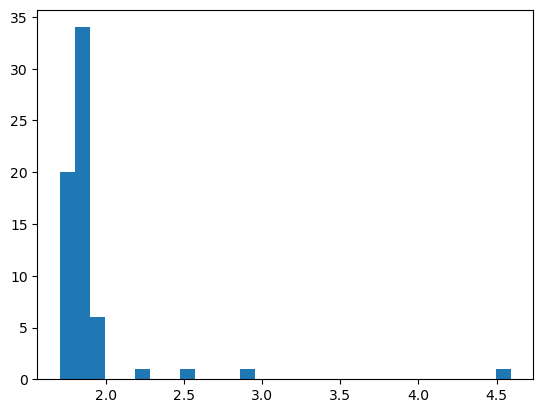

: 

In [29]:
plt.hist(df["alignment.motif_allatom_align.motif_allatom_rmsd"], bins=30)

In [34]:
seqs = glob.glob("/home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_00*/*.cif")

for s in seqs:
    print(f"load {s}")

load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0014/seq_0014_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0007/seq_0007_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0000/seq_0000_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0013/seq_0013_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0004/seq_0004_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_0499/af3/outputs/seq_0009/seq_0009_model.cif
load /home/jgershon/projects/itopt/policy_mpnn/protease_vanilla_pg/pipeline_output/pipeline_output_iter_04

: 

: 